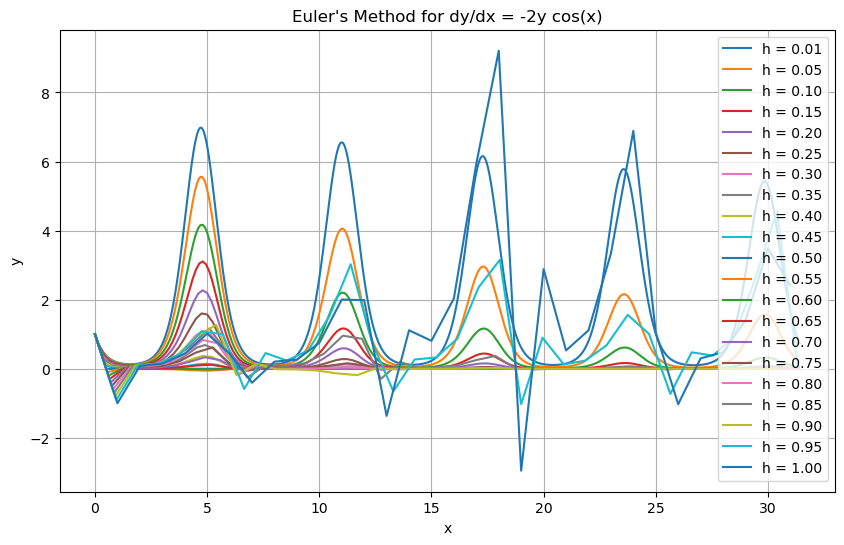

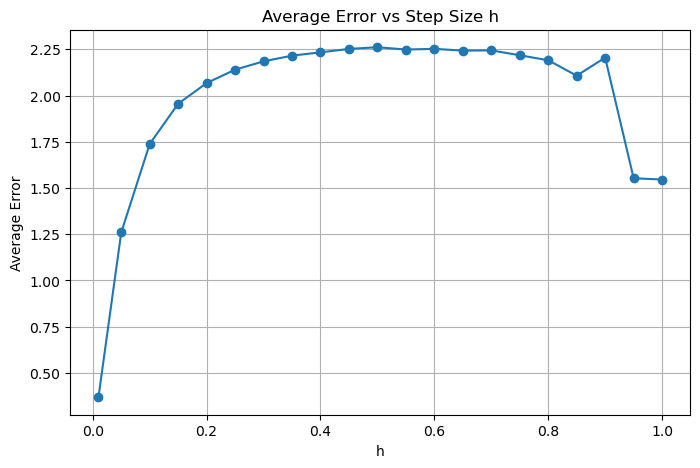

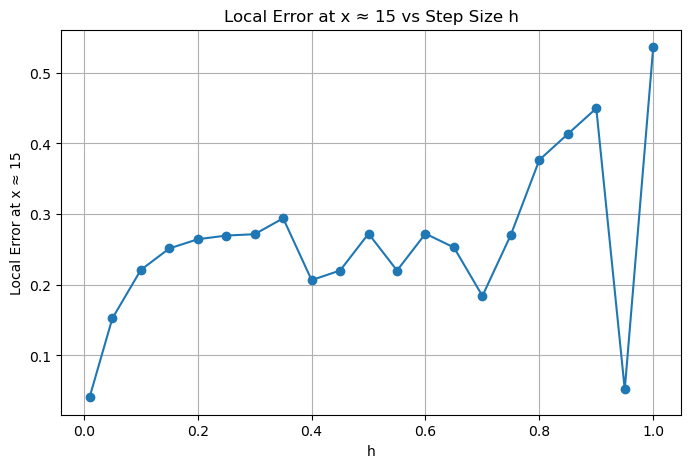

h	Average y	Average Error	y at x≈15	Local Error at x≈15
0.01	1.910827	0.368593	0.231440	0.040935
0.05	1.018602	1.259614	0.119869	0.152506
0.10	0.538068	1.738144	0.051318	0.221057
0.15	0.320505	1.955839	0.020921	0.251454
0.20	0.204568	2.067651	0.007903	0.264472
0.25	0.136335	2.140288	0.002662	0.269713
0.30	0.091602	2.185167	0.000753	0.271622
0.35	0.061013	2.215906	0.000170	0.294172
0.40	0.039514	2.233876	0.000018	0.206679
0.45	0.024970	2.252260	0.000001	0.220242
0.50	0.015873	2.261520	0.000000	0.272375
0.55	0.011968	2.249053	0.000000	0.220243
0.60	0.013873	2.252663	-0.000000	0.272375
0.65	0.021701	2.243102	0.000016	0.252852
0.70	0.033776	2.244302	0.000005	0.184239
0.75	0.060223	2.218037	0.001574	0.270801
0.80	0.068476	2.191062	0.001268	0.376756
0.85	0.172581	2.107630	0.038863	0.413405
0.90	0.073782	2.205192	0.002522	0.449745
0.95	0.789850	1.552940	0.326151	0.051873
1.00	1.392470	1.545959	0.808593	0.536218


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ChatGPT was used to help organize and check this code.

def f(x, y):
    return -2 * y * np.cos(x)

def exact_solution(x):
    return np.exp(-2 * np.sin(x))

def euler_method(h, x0, x_end, y0):
    x_values = np.arange(x0, x_end + h, h)
    if x_values[-1] > x_end:
        x_values = x_values[:-1]

    y_values = np.zeros(len(x_values))
    y_values[0] = y0

    for i in range(len(x_values) - 1):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values

# Interval and initial condition
x0 = 0
x_end = 10 * np.pi
y0 = 1

# Step sizes: 0.01, 0.05, 0.10, 0.15, ..., 1.00
h_values = [0.01] + list(np.arange(0.05, 1.05, 0.05))

avg_y_list = []
avg_error_list = []
local_error_list = []
y_at_15_list = []

# Plot 1: Euler's method for each h
plt.figure(figsize=(10, 6))

for h in h_values:
    x_vals, y_vals = euler_method(h, x0, x_end, y0)
    y_exact = exact_solution(x_vals)

    avg_y = np.mean(y_vals)
    avg_error = np.mean(np.abs(y_vals - y_exact))

    idx_15 = np.argmin(np.abs(x_vals - 15))
    x_near_15 = x_vals[idx_15]
    y_near_15 = y_vals[idx_15]
    exact_near_15 = exact_solution(x_near_15)
    local_error = abs(y_near_15 - exact_near_15)

    avg_y_list.append(avg_y)
    avg_error_list.append(avg_error)
    local_error_list.append(local_error)
    y_at_15_list.append(y_near_15)

    plt.plot(x_vals, y_vals, label=f"h = {h:.2f}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for dy/dx = -2y cos(x)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Average error vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_error_list, marker='o')
plt.xlabel("h")
plt.ylabel("Average Error")
plt.title("Average Error vs Step Size h")
plt.grid(True)
plt.show()

# Plot 3: Local error at x ≈ 15 vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, local_error_list, marker='o')
plt.xlabel("h")
plt.ylabel("Local Error at x ≈ 15")
plt.title("Local Error at x ≈ 15 vs Step Size h")
plt.grid(True)
plt.show()

# Print results table
print("h\tAverage y\tAverage Error\ty at x≈15\tLocal Error at x≈15")
for i in range(len(h_values)):
    print(f"{h_values[i]:.2f}\t{avg_y_list[i]:.6f}\t{avg_error_list[i]:.6f}\t{y_at_15_list[i]:.6f}\t{local_error_list[i]:.6f}")

For smaller step sizes, Euler’s method is more accurate because it updates the solution more often and follows the curve more closely. As the step size increases, both the average error and the local error near x≈15 increase because Euler’s method accumulates more numerical error over larger steps. This is why the plots show that smaller h values give better approximations than larger h values.